In [1]:
using LinearAlgebra
using Random
using PythonPlot

## Attitude Sensors Revisited

In [3]:
# q = [scalar; vector] -- Q(q) maps body -> inertial: r_N = Q(q)*r_B
function hat(v)
    return [0 -v[3] v[2]; v[3] 0 -v[1]; -v[2] v[1] 0]
end
function unhat(S)
    return 0.5*[S[3,2]-S[2,3]; S[1,3]-S[3,1]; S[2,1]-S[1,2]]
end
H = [zeros(1,3); I(3)]
function L(q)
    return [q[1] -q[2:4]'; q[2:4] q[1]*I(3) + hat(q[2:4])]
end
function R(q)
    return [q[1] -q[2:4]'; q[2:4] q[1]*I(3) - hat(q[2:4])]
end
G(q) = L(q)*H
Q(q) = H'*(R(q)'*L(q))*H
function expq(phi)
    theta = norm(phi)
    return [cos(theta); phi*sinc(theta/pi)]
end
function logq(q)
    c = q[1]; s = norm(q[2:4]); theta = atan(s, c)
    return q[2:4] / sinc(theta/pi)
end
sample_noise(W) = cholesky(Symmetric(Matrix(W))).L * randn(3)

sample_noise (generic function with 1 method)

## 1. Affine Vector Sensor Models

In [4]:
# Sun sensor: AAC Clyde Space SS200
sigma_sun = 0.3 * (pi/180)
M_sun     = I(3)
b_sun     = zeros(3)
W_sun     = sigma_sun^2 * I(3)

# Magnetometer: representative 3-axis unit (±60,000 nT range, ≤8 nT resolution)

sigma_mag = 1.0 * (pi/180)
M_mag     = [ 1.0       1.745e-2  0.0;
             -1.745e-2  1.0       0.0;
              0.0       0.0       1.0]
b_mag     = [4.4e-3, 2.2e-3, 3.3e-3]
W_mag     = sigma_mag^2 * I(3)

affine_vector_meas(v, M, b, W) = normalize(M*v + b + sample_noise(W))

println("Sun sensor:   M = I, b = 0  (factory calibrated, no residual spec)")
println("Magnetometer: misalign = 1.0 deg,  |b| = $(round(norm(b_mag), digits=4)) (~0.25 deg at 45,000 nT)")

Sun sensor:   M = I, b = 0  (factory calibrated, no residual spec)
Magnetometer: misalign = 1.0 deg,  |b| = 0.0059 (~0.25 deg at 45,000 nT)


## 2. Star Tracker Model

In [5]:
# Blue Canyon NST: 6 arcsec cross-boresight, 40 arcsec about-boresight (same as HW2)
# Measurement: q_meas = L(q_true) * expq(w),  w ~ N(0, W_st)
sigma_st_cross = 6.0*(pi/180)/3600
sigma_st_bore  = 40.0*(pi/180)/3600
W_st = Diagonal([sigma_st_cross^2, sigma_st_cross^2, sigma_st_bore^2])

function star_tracker_meas(q_true, W_st_mat)
    w = cholesky(Symmetric(Matrix(W_st_mat))).L * randn(3)
    return normalize(L(q_true) * expq(w))
end

q_st_true = [1.0, 0.0, 0.0, 0.0]
N_mc = 10_000
dphi = zeros(3, N_mc)
for i in 1:N_mc
    q_meas = star_tracker_meas(q_st_true, Matrix(W_st))
    dphi[:, i] = 2*logq(L(q_st_true)' * q_meas)
end
cov_st = (dphi * dphi') / (N_mc - 1)
s1, s2, s3 = [round(sqrt(cov_st[i,i])*(180/pi)*3600, digits=2) for i in 1:3]
println("Star tracker (N=$(N_mc)): sigma = $s1, $s2, $s3 arcsec  (intended: 6, 6, 40 arcsec)")

Star tracker (N=10000): sigma = 12.06, 12.09, 80.21 arcsec  (intended: 6, 6, 40 arcsec)


## 3. Gyroscope Error Model

In [6]:
# ADIS16470 MEMS gyro (Analog Devices datasheet Rev. C, TC = 25°C, ±2000°/s range)
h_gyro = 0.1  # 10 Hz

ARW_rad_sqrts = 0.34*(pi/180)/60
sigma_omega   = ARW_rad_sqrts/sqrt(h_gyro)
V_omega       = sigma_omega^2 * I(3)

sigma_drift = 8.0*(pi/180)/3600
sigma_beta  = sigma_drift*sqrt(h_gyro)/sqrt(3600.0)
V_beta      = sigma_beta^2 * I(3)

# ±0.25% scale factor, ±0.1 deg misalignment (sin(0.1 deg) ≈ 1.745e-3)
M_gyro = [ 1.0025   1.745e-3  0.0;
          -1.745e-3  0.9975   0.0;
           0.0       0.0      1.0]

println("sigma_omega = $(round(sigma_omega*(180/pi)*3600, digits=2)) arcsec/s  (ARW 0.34 deg/sqrt(hr) at 10 Hz)")
println("sigma_beta  = $(round(sigma_beta*sqrt(3600/h_gyro)*(180/pi), digits=3)) deg/hr 1-sigma drift over 1 hr")

sigma_omega = 64.51 arcsec/s  (ARW 0.34 deg/sqrt(hr) at 10 Hz)
sigma_beta  = 0.002 deg/hr 1-sigma drift over 1 hr


Saved figs/gyro_random_walk.png


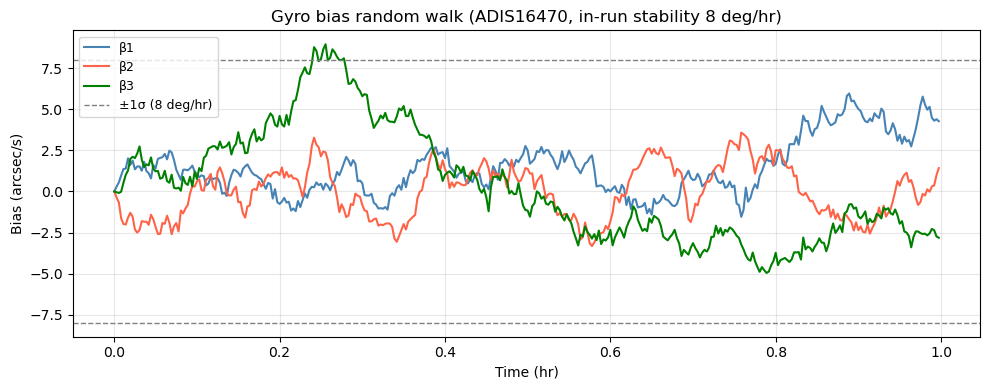

In [7]:
gyro_meas_fn(omega, beta, M, V) = M*omega + beta + cholesky(Symmetric(Matrix(V))).L*randn(3)

omega_true = [0.01, 0.005, -0.003]
n_sim      = 36000
t_sim      = (0:n_sim-1) .* h_gyro

beta_traj = zeros(3, n_sim)
gyro_traj = zeros(3, n_sim)
L_beta    = cholesky(Symmetric(Matrix(V_beta))).L
for k in 1:n_sim
    gyro_traj[:, k] = gyro_meas_fn(omega_true, beta_traj[:, k], M_gyro, V_omega)
    if k < n_sim
        beta_traj[:, k+1] = beta_traj[:, k] + L_beta*randn(3)
    end
end

cols = ["steelblue", "tomato", "green"]
ds   = 100
t_hr = t_sim[1:ds:end] ./ 3600

fig, ax = subplots(figsize=(10, 4))
for i in 1:3
    ax.plot(t_hr, beta_traj[i, 1:ds:end]*(180/pi)*3600; color=cols[i], linewidth=1.5, label="β$(i)")
end
ax.axhline( sigma_drift*(180/pi)*3600; color="gray", linewidth=1.0, linestyle="--", label="±1σ (8 deg/hr)")
ax.axhline(-sigma_drift*(180/pi)*3600; color="gray", linewidth=1.0, linestyle="--")
ax.set_xlabel("Time (hr)")
ax.set_ylabel("Bias (arcsec/s)")
ax.set_title("Gyro bias random walk (ADIS16470, in-run stability 8 deg/hr)")
ax.legend(fontsize=9); ax.grid(true, alpha=0.3)
tight_layout()
savefig("figs/gyro_random_walk.png"; dpi=150, bbox_inches="tight")
println("Saved figs/gyro_random_walk.png")